# Графики для главы 4: анализ остаточных напряжений

Полный набор кода для построения всех графиков, использованных в главе 4 ВКР. Все графики строятся на основе уже обученных моделей и оригинального датасета.

**Требуемые файлы в `/content/`:**
- `X_stress.pkl`, `y_stress.pkl` — обучающий датасет (cleaned, 2028 наборов)
- `mlp_model_grid.pkl`, `mlp_model.pkl` — MLP baseline и Optuna
- `pinn_model_torch.pkl`, `pinn_model_dde.pkl`, `pinn_model_jax.pkl` — три PINN
- `vpinn_model.pkl` — variational PINN

Все six бандлов содержат `holdout_set_indices` с одинаковым `SPLIT_SEED=42`.

## Ячейка 1. Конфигурация, загрузка данных, утилиты

In [2]:
import pickle
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

N_R = 20
PLANE_ORDER = [2, 0, 1, 3]
SPLIT_SEED = 42
HOLDOUT_FRAC = 0.15

STRESS_NAMES = ["sigma_rr", "sigma_tt", "sigma_zz", "tau_rz"]
COMP_TEX = [r"$\sigma_{rr}$", r"$\sigma_{\theta\theta}$",
             r"$\sigma_{zz}$", r"$\tau_{rz}$"]

DATA_X = "/content/X_stress.pkl"
DATA_Y = "/content/y_stress.pkl"

BUNDLE_PATHS = {
    "MLP-grid":   "/content/mlp_model_grid.pkl",
    "MLP-Optuna": "/content/mlp_model.pkl",
    "PINN-torch": "/content/pinn_model_torch.pkl",
    "PINN-dde":   "/content/pinn_model_dde.pkl",
    "PINN-jax":   "/content/pinn_model_jax.pkl",
    "VPINN":      "/content/vpinn_model.pkl",
}

MODEL_COLORS = {
    "MLP-grid":   "#ff7f0e",
    "MLP-Optuna": "#ffbb78",
    "PINN-torch": "#1f77b4",
    "PINN-dde":   "#17becf",
    "PINN-jax":   "#aec7e8",
    "VPINN":      "#2ca02c",
}
MODEL_LABELS = {
    "MLP-grid":   "MLP (grid)",
    "MLP-Optuna": "MLP (Optuna)",
    "PINN-torch": "PINN (PyTorch)",
    "PINN-dde":   "PINN (DeepXDE)",
    "PINN-jax":   "PINN (JAX/Flax)",
    "VPINN":      "VPINN",
}

plt.rcParams.update({
    "font.family": "serif", "font.size": 10,
    "axes.linewidth": 0.8, "axes.grid": True,
    "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

# Загрузка X_stress, y_stress
with open(DATA_X, "rb") as f: X_stress = pickle.load(f)
with open(DATA_Y, "rb") as f: y_stress = pickle.load(f)

n_sets = X_stress.shape[1]
proc = X_stress[0].astype(np.float32)
r_grid = np.linspace(0.0, 1.0, N_R, dtype=np.float32)

proc_rep = np.repeat(proc, N_R, axis=0)
r_rep = np.tile(r_grid, n_sets)[:, None]
X_full = np.hstack([proc_rep, r_rep]).astype(np.float32)
y_full = np.stack([y_stress[PLANE_ORDER[i]].reshape(-1) for i in range(4)],
                   axis=1).astype(np.float32)

rng = np.random.default_rng(SPLIT_SEED)
n_hold = max(1, int(round(n_sets * HOLDOUT_FRAC)))
hold_sets = np.sort(rng.choice(np.arange(n_sets), size=n_hold, replace=False))
hold_rows = np.concatenate([np.arange(s * N_R, (s + 1) * N_R) for s in hold_sets])
X_hold, y_hold = X_full[hold_rows], y_full[hold_rows]

print(f"N_sets total: {n_sets}")
print(f"Holdout: {len(hold_sets)} sets, {len(hold_rows)} rows")
print(f"X_hold.shape={X_hold.shape}, y_hold.shape={y_hold.shape}")


def _layer_idx(key):
    m = re.search(r"(\d+)", key)
    return int(m.group(1)) if m else 0


def extract_layers(bundle):
    sd = bundle.get("torch_state_dict")
    if sd is not None:
        wk = sorted([k for k in sd if k.endswith(".weight")], key=_layer_idx)
        bk = sorted([k for k in sd if k.endswith(".bias")],   key=_layer_idx)
        Ws = [np.asarray(sd[k]) for k in wk]
        bs = [np.asarray(sd[k]) for k in bk]
    else:
        params = bundle["flax_params_numpy"]
        lk = sorted(params.keys(), key=_layer_idx)
        Ws = [np.asarray(params[k]["kernel"]).T for k in lk]
        bs = [np.asarray(params[k]["bias"])    for k in lk]
    return Ws, bs, bundle.get("activation", "tanh")


def forward_predict(bundle, X_input):
    Ws, bs, act = extract_layers(bundle)
    mx = np.asarray(bundle["mean_X"]).reshape(-1)
    sx = np.asarray(bundle["std_X"]).reshape(-1)
    sym = np.asarray(bundle["scaler_y_mean"]).reshape(-1)
    sys_ = np.asarray(bundle["scaler_y_std"]).reshape(-1)
    h = ((X_input.astype(np.float32) - mx) / sx)
    for i, (W, B) in enumerate(zip(Ws, bs)):
        h = h @ W.T + B
        if i < len(Ws) - 1:
            if act == "tanh":
                h = np.tanh(h)
            elif act == "selu":
                alpha, lam = 1.6732632, 1.050700987
                h = lam * np.where(h > 0, h, alpha * (np.exp(np.minimum(h, 50)) - 1))
            elif act == "softplus":
                h = np.log1p(np.exp(-np.abs(h))) + np.maximum(h, 0)
            else:
                raise ValueError(f"unknown activation: {act}")
    return h * sys_ + sym


def von_mises(sigma):
    rr, tt, zz, tr = (sigma[:, i] for i in range(4))
    dev = 0.5 * ((rr - tt) ** 2 + (tt - zz) ** 2 + (zz - rr) ** 2)
    return np.sqrt(np.maximum(dev + 3.0 * tr ** 2, 0.0))


def smape(yt, yp, eps=1e-8):
    yt, yp = yt.ravel(), yp.ravel()
    den = (np.abs(yt) + np.abs(yp)) / 2 + eps
    return float(100 * np.mean(np.abs(yt - yp) / den))


# Загрузка всех 6 бандлов
BUNDLES = {}
for name, path in BUNDLE_PATHS.items():
    if Path(path).exists():
        with open(path, "rb") as f:
            BUNDLES[name] = pickle.load(f)
    else:
        print(f"[skip] {name}: {path} not found")

# Проверка консистентности holdout
for name, b in BUNDLES.items():
    bh = np.asarray(b.get("holdout_set_indices", []))
    ok = "✓" if np.array_equal(np.sort(bh), hold_sets) else "✗"
    print(f"  {name:12s} : holdout_set_indices {ok}")

N_sets total: 2028
Holdout: 304 sets, 6080 rows
X_hold.shape=(6080, 6), y_hold.shape=(6080, 4)
  MLP-grid     : holdout_set_indices ✓
  MLP-Optuna   : holdout_set_indices ✓
  PINN-torch   : holdout_set_indices ✓
  PINN-dde     : holdout_set_indices ✓
  PINN-jax     : holdout_set_indices ✓
  VPINN        : holdout_set_indices ✓


## Ячейка 2. Инференс на holdout и рейтинг моделей

Воспроизводит метрики из бандлов (sanity-check) и формирует сводный рейтинг.

In [3]:
predictions = {}
rows = []
for name, b in BUNDLES.items():
    y_pred = forward_predict(b, X_hold)
    predictions[name] = y_pred

    yt_flat, yp_flat = y_hold.reshape(-1), y_pred.reshape(-1)
    r2 = r2_score(yt_flat, yp_flat)
    rmse = float(np.mean([np.sqrt(mean_squared_error(y_hold[:, i], y_pred[:, i]))
                           for i in range(4)]))
    mae = float(np.mean(np.abs(y_hold - y_pred)))
    sm = smape(yt_flat, yp_flat)
    vm_t, vm_p = von_mises(y_hold), von_mises(y_pred)
    vm_r2 = r2_score(vm_t, vm_p)
    vm_rmse = float(np.sqrt(mean_squared_error(vm_t, vm_p)))
    pc_r2 = [r2_score(y_hold[:, i], y_pred[:, i]) for i in range(4)]
    rows.append({
        "Model": name, "R²": r2, "RMSE [МПа]": rmse,
        "VM R²": vm_r2, "VM RMSE [МПа]": vm_rmse,
        "SMAPE [%]": sm, "MAE": mae,
        "R²(σ_rr)": pc_r2[0], "R²(σ_θθ)": pc_r2[1],
        "R²(σ_zz)": pc_r2[2], "R²(τ_rz)": pc_r2[3],
    })

df_rank = pd.DataFrame(rows).sort_values("RMSE [МПа]").reset_index(drop=True)
df_rank.insert(0, "Rank", range(1, len(df_rank) + 1))

with pd.option_context("display.float_format", "{:,.4f}".format,
                        "display.width", 200, "display.max_columns", None):
    print(df_rank.to_string(index=False))

print(f"\nЛучшая модель: {df_rank.iloc[0]['Model']}  RMSE={df_rank.iloc[0]['RMSE [МПа]']:.3f} МПа")

 Rank      Model     R²  RMSE [МПа]  VM R²  VM RMSE [МПа]  SMAPE [%]    MAE  R²(σ_rr)  R²(σ_θθ)  R²(σ_zz)  R²(τ_rz)
    1   PINN-jax 0.9817     11.5120 0.9482        17.0344    28.4411 6.6136    0.9779    0.9650    0.9773    0.9865
    2 PINN-torch 0.9802     11.9624 0.9490        16.9085    28.0824 6.9575    0.9739    0.9650    0.9754    0.9859
    3      VPINN 0.9802     12.1357 0.9397        18.3856    27.3391 6.8335    0.9705    0.9720    0.9753    0.9783
    4   PINN-dde 0.9792     12.3648 0.9414        18.1166    28.5261 7.4905    0.9710    0.9672    0.9730    0.9818
    5 MLP-Optuna 0.9778     12.6213 0.9340        19.2331    31.8838 7.7706    0.9686    0.9631    0.9739    0.9841
    6   MLP-grid 0.9761     13.2198 0.9352        19.0620    31.4338 8.1854    0.9660    0.9637    0.9683    0.9803

Лучшая модель: PINN-jax  RMSE=11.512 МПа


## Ячейка 3. Профильные графики для одного режима

Строит четыре панели $\sigma_{rr}, \sigma_{\theta\theta}, \sigma_{zz}, \tau_{rz}$ для одного набора параметров. Чёрная сплошная — FEM, цветные пунктирные — предсказания шести моделей.

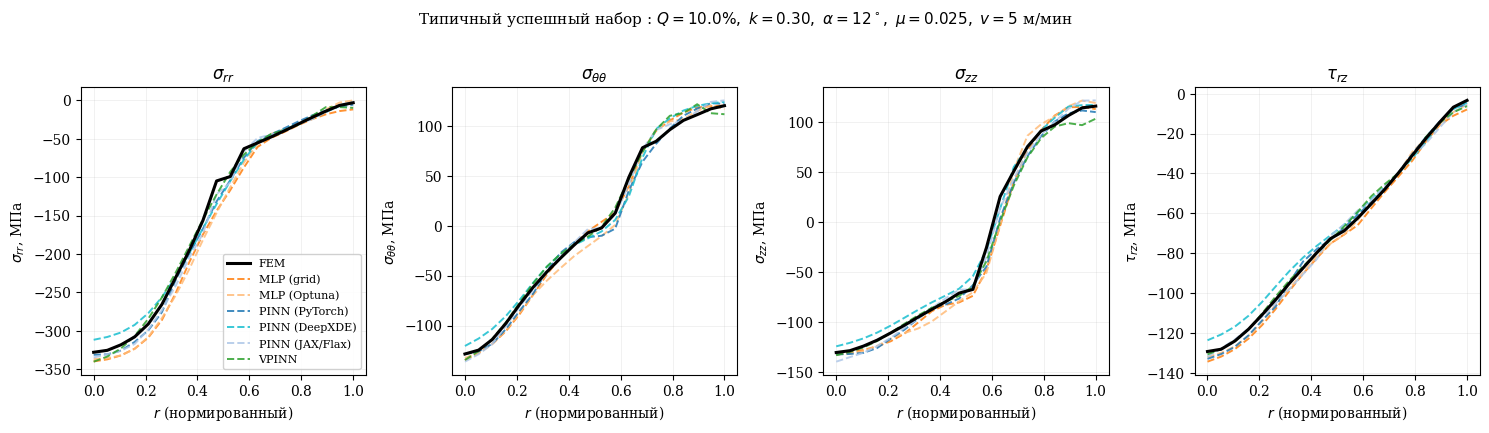

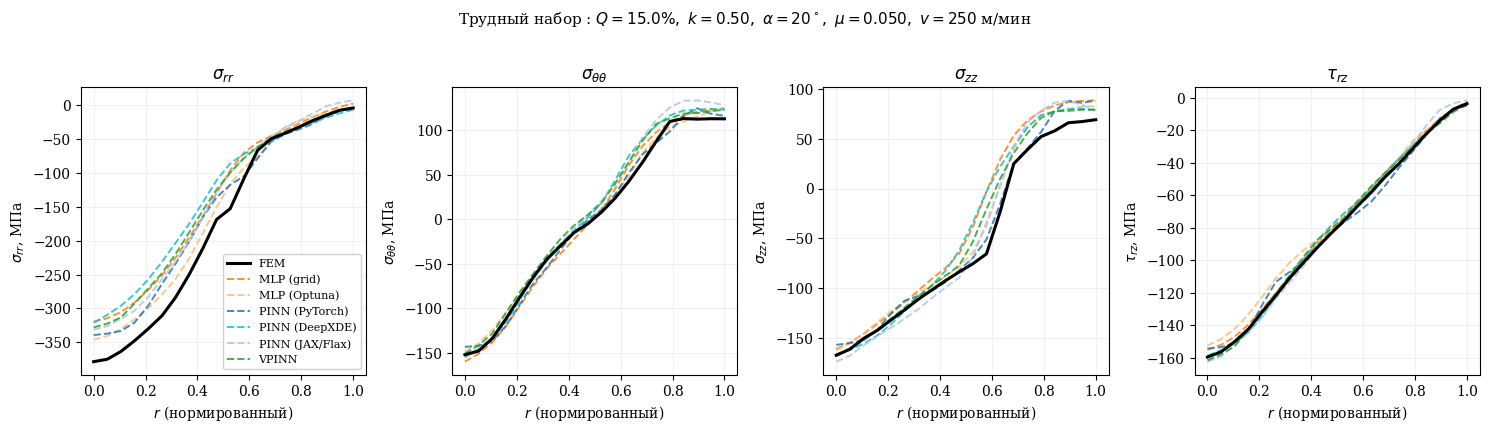

In [4]:
# Найдём типичный (median по avg RMSE) и трудный (95-перцентиль) наборы
all_pred_set = {n: predictions[n].reshape(len(hold_sets), N_R, 4) for n in BUNDLES}
y_hold_set = y_hold.reshape(len(hold_sets), N_R, 4)

rmse_per_set = np.zeros((len(hold_sets), len(BUNDLES)))
for j, name in enumerate(BUNDLES):
    diff2 = (all_pred_set[name] - y_hold_set) ** 2
    rmse_per_set[:, j] = np.sqrt(diff2.mean(axis=(1, 2)))
avg_rmse = rmse_per_set.mean(axis=1)
good_idx = int(np.argsort(avg_rmse)[len(avg_rmse) // 2])
bad_idx  = int(np.argsort(avg_rmse)[int(len(avg_rmse) * 0.95)])


def profile_plot(local_idx, suptitle, save_to=None):
    p = proc[hold_sets[local_idx]]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharex=True)
    for c, ax in enumerate(axes):
        ax.plot(r_grid, y_hold_set[local_idx, :, c], "k-", lw=2.2,
                label="FEM", zorder=10)
        for name in BUNDLES:
            ax.plot(r_grid, all_pred_set[name][local_idx, :, c], "--",
                    color=MODEL_COLORS[name], lw=1.4, alpha=0.85,
                    label=MODEL_LABELS[name])
        ax.set_xlabel(r"$r$ (нормированный)", fontsize=10)
        ax.set_ylabel(f"{COMP_TEX[c]}, МПа", fontsize=10)
        ax.set_title(COMP_TEX[c], fontsize=12)
        if c == 0:
            ax.legend(fontsize=8, loc="best", framealpha=0.9)
    fig.suptitle(rf"{suptitle} : $Q={p[0]*100:.1f}\%,\ k={p[1]:.2f},\ "
                  rf"\alpha={p[2]:.0f}^\circ,\ \mu={p[3]:.3f},\ v={p[4]:.0f}$ м/мин",
                  fontsize=11, y=1.02)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=300, bbox_inches="tight")
    plt.show()


profile_plot(good_idx, "Типичный успешный набор", "/content/profile_stress_good.png")
profile_plot(bad_idx,  "Трудный набор",            "/content/profile_stress_bad.png")

## Ячейка 4. Точечные диаграммы попадания для шести моделей

Для каждой модели — отдельная фигура с пятью панелями (четыре компоненты тензора + фон Мизеса).

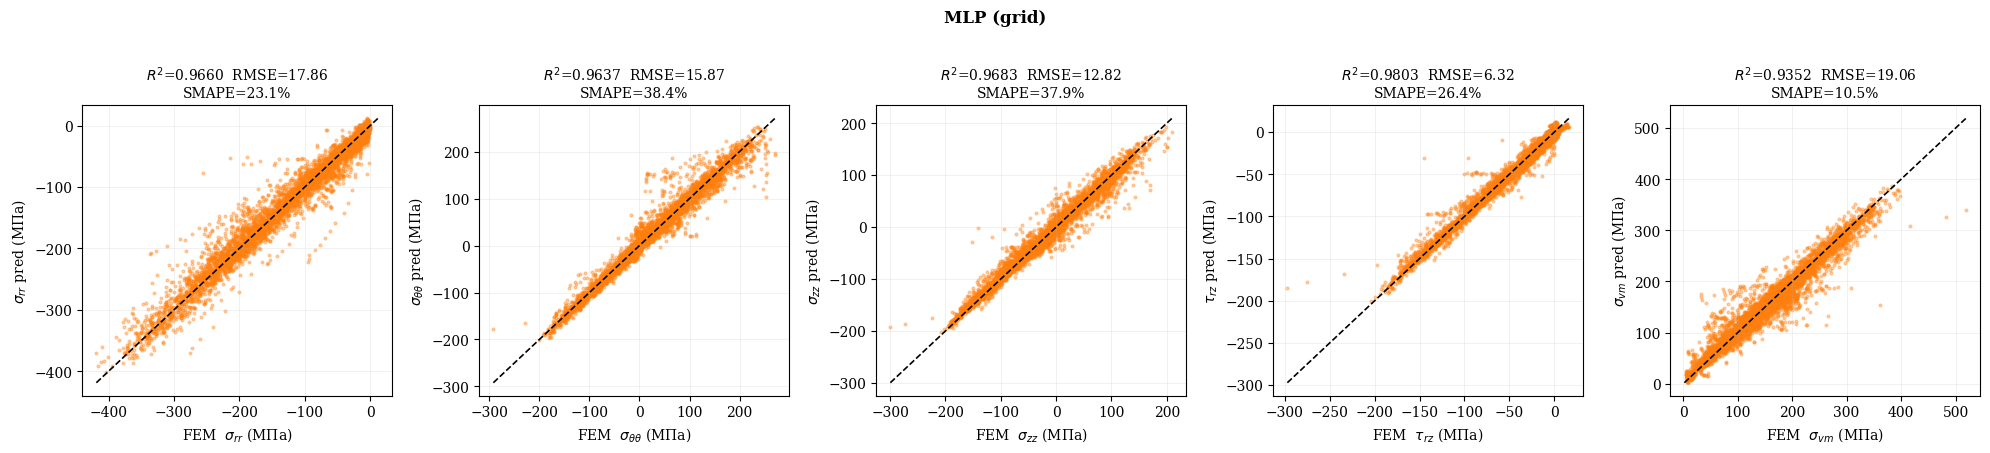

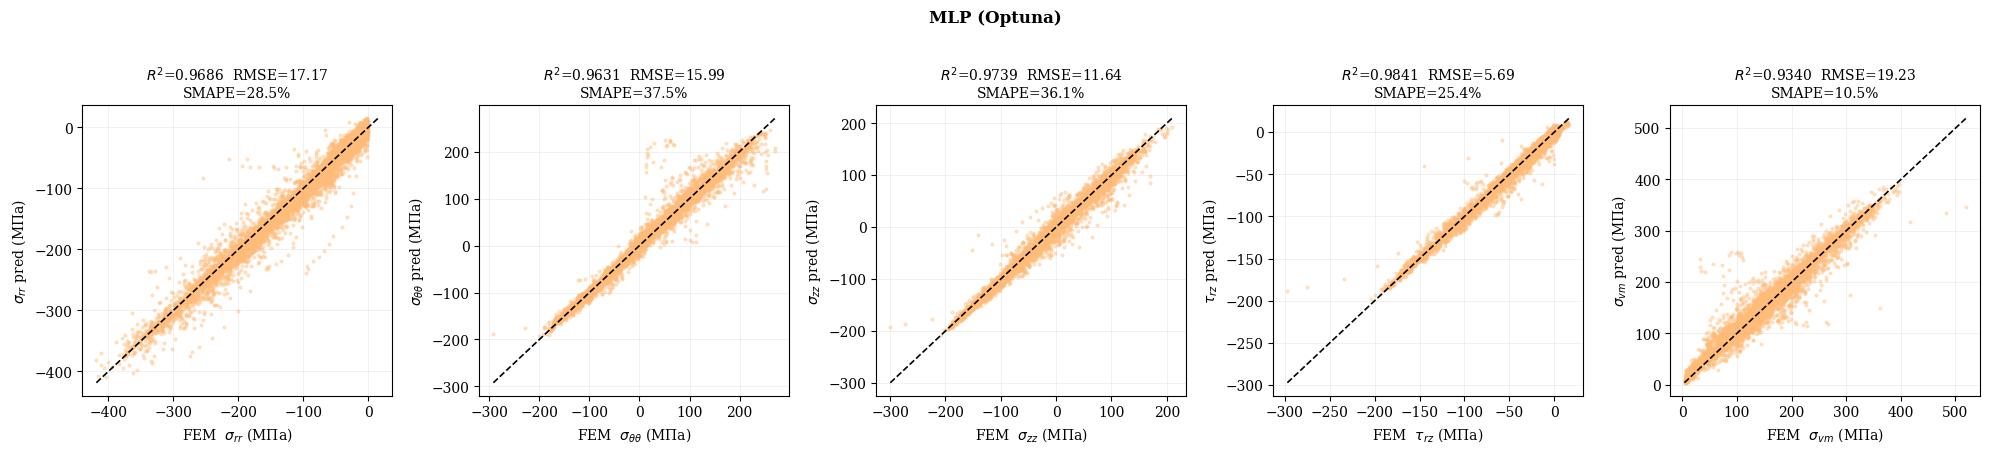

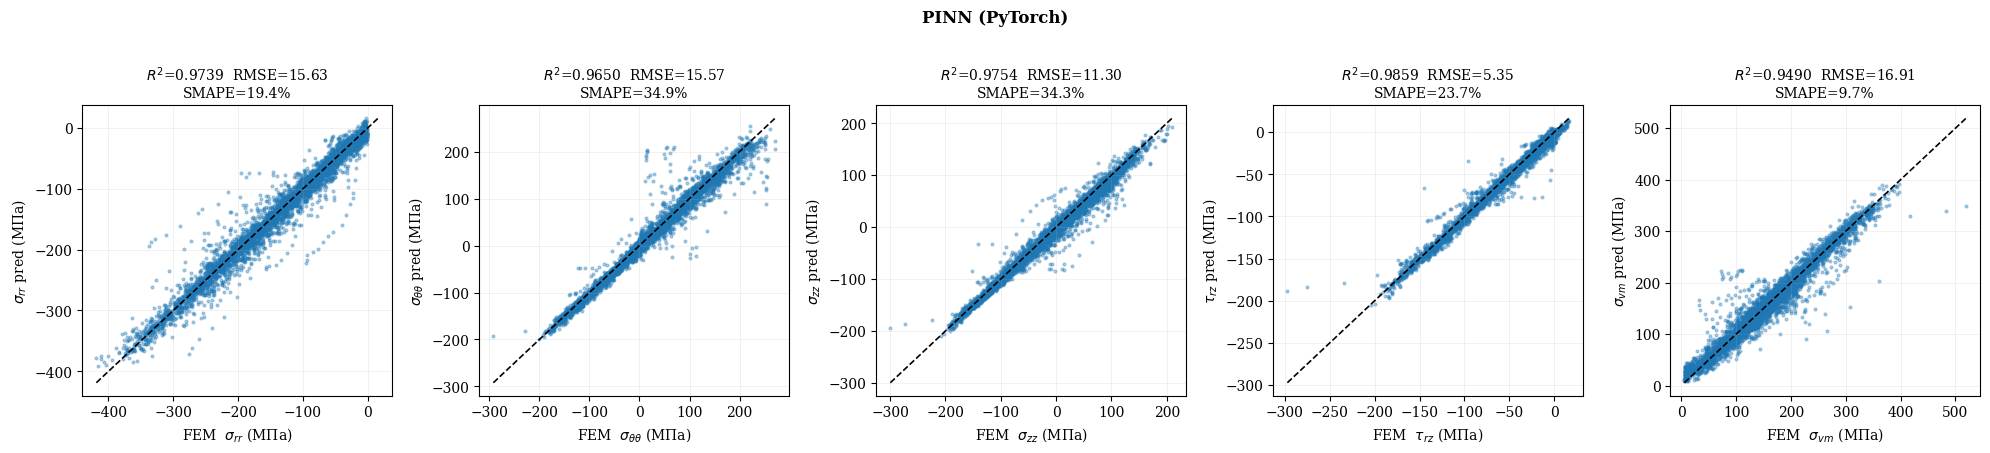

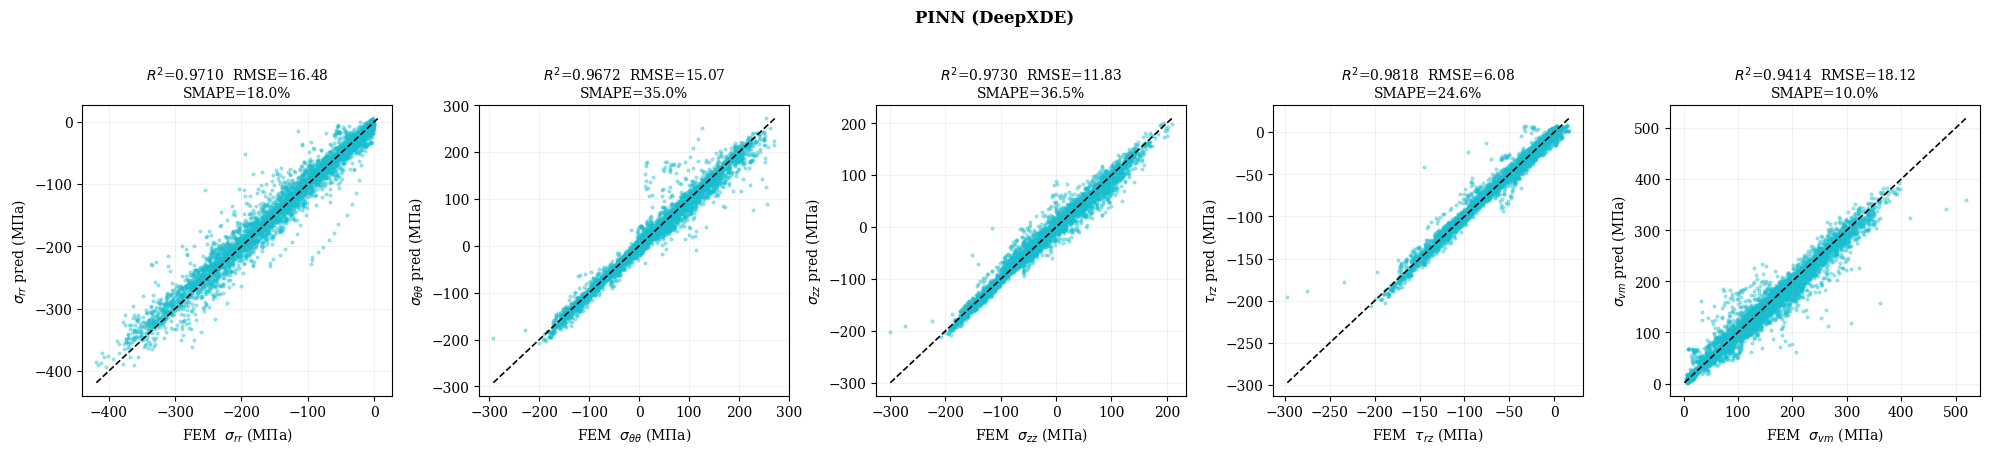

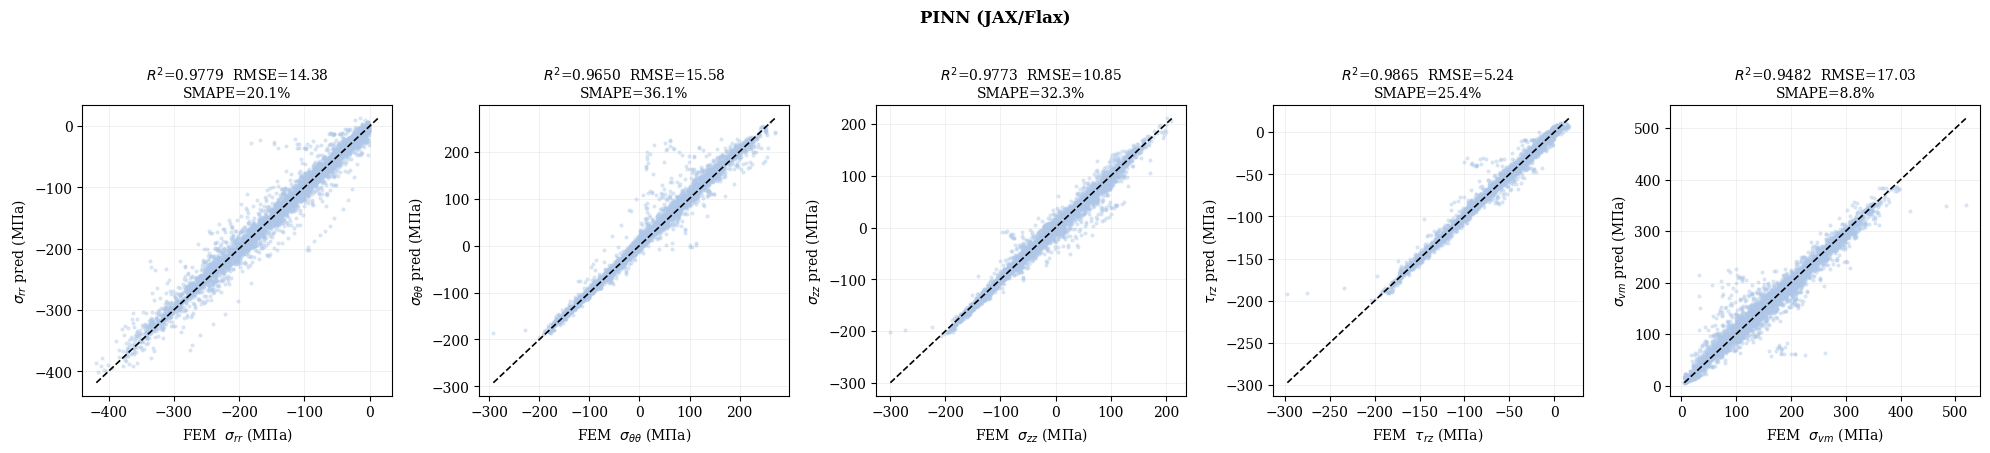

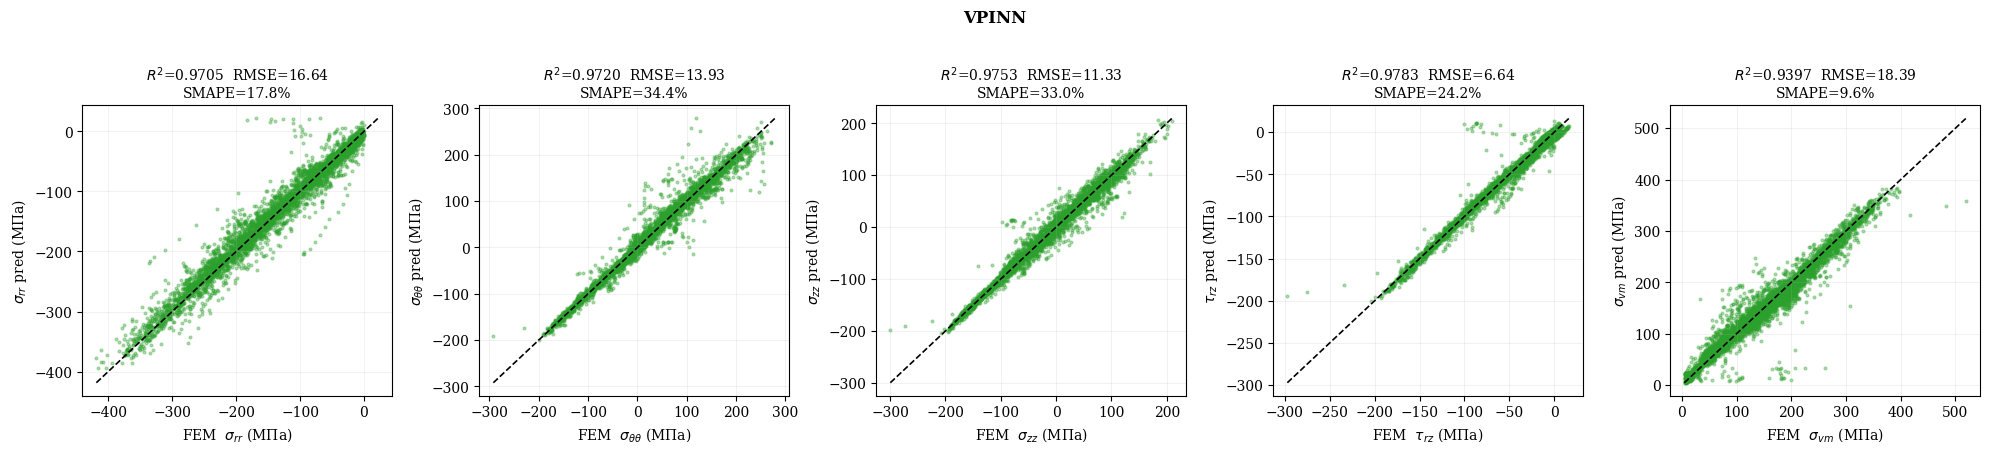

In [5]:
titles = COMP_TEX + [r"$\sigma_{vm}$"]
for name in BUNDLES:
    y_pred = predictions[name]
    fig, axes = plt.subplots(1, 5, figsize=(20, 4.4))
    for c, ax in enumerate(axes):
        if c < 4:
            yt = y_hold[:, c]; yp = y_pred[:, c]
        else:
            yt = von_mises(y_hold); yp = von_mises(y_pred)
        r2 = r2_score(yt, yp)
        rm = np.sqrt(mean_squared_error(yt, yp))
        sm = smape(yt, yp)
        ax.scatter(yt, yp, s=4, alpha=0.35, color=MODEL_COLORS[name])
        lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1.2)
        ax.set_xlabel(f"FEM  {titles[c]} (МПа)", fontsize=10)
        ax.set_ylabel(f"{titles[c]} pred (МПа)", fontsize=10)
        ax.set_title(f"$R^2$={r2:.4f}  RMSE={rm:.2f}\nSMAPE={sm:.1f}%", fontsize=10)
    fig.suptitle(MODEL_LABELS[name], fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    safe = name.lower().replace("-", "_").replace("(", "").replace(")", "")
    plt.savefig(f"/content/scatter_stress_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Ячейка 5. Нарушение граничного условия на свободной поверхности

Зондирование моделей в точке $r_{\mathrm{norm}}=1{,}5$ (физическая свободная поверхность $r=R$). PINN-модели были обучены с граничным условием $\sigma_{rr}=\tau_{rz}=0$ в этой точке через слагаемое $\lambda_{\mathrm{bc}}\mathcal{L}_{\mathrm{bc}}$ в функции потерь. MLP-модели не имеют такого механизма и здесь работают в режиме экстраполяции.

  MLP-grid    : |σ_rr|=8.440  |τ_rz|=8.916
  MLP-Optuna  : |σ_rr|=16.414  |τ_rz|=11.183
  PINN-torch  : |σ_rr|=0.490  |τ_rz|=0.294
  PINN-dde    : |σ_rr|=1.079  |τ_rz|=0.240
  PINN-jax    : |σ_rr|=0.441  |τ_rz|=0.483
  VPINN       : |σ_rr|=0.643  |τ_rz|=0.628


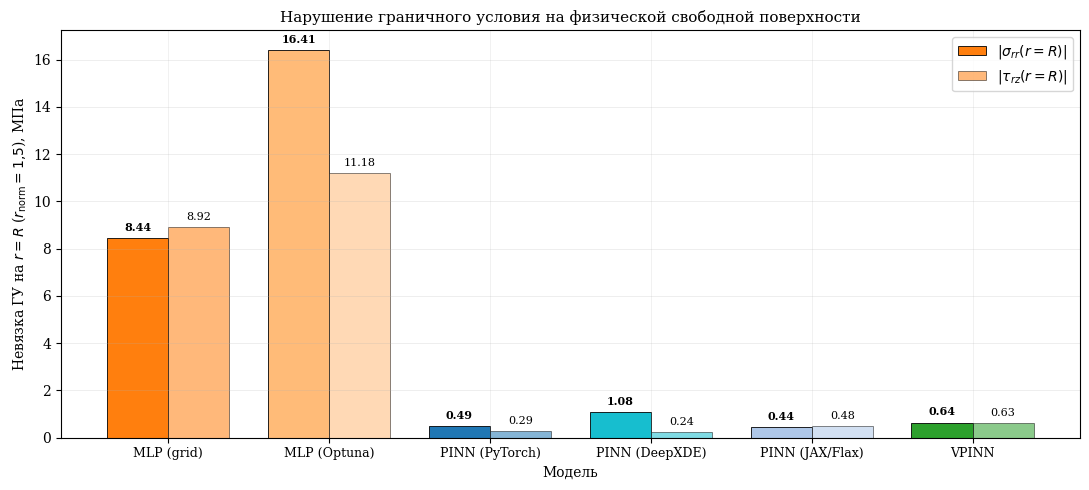

In [6]:
# Берём по одной строке на каждый holdout-набор и заменяем r на 1.5
X_probe = X_hold[N_R-1::N_R].copy()
X_probe[:, 5] = 1.5

bc_data = {}
for name, b in BUNDLES.items():
    yp = forward_predict(b, X_probe)
    bc_data[name] = {
        "srr_mean": float(np.abs(yp[:, 0]).mean()),
        "trz_mean": float(np.abs(yp[:, 3]).mean()),
        "srr_med":  float(np.median(np.abs(yp[:, 0]))),
        "trz_med":  float(np.median(np.abs(yp[:, 3]))),
    }
    print(f"  {name:12s}: |σ_rr|={bc_data[name]['srr_mean']:.3f}  "
          f"|τ_rz|={bc_data[name]['trz_mean']:.3f}")

fig, ax = plt.subplots(figsize=(11, 5))
order = list(BUNDLES.keys())
x = np.arange(len(order))
w = 0.38
srr_vals = [bc_data[n]["srr_mean"] for n in order]
trz_vals = [bc_data[n]["trz_mean"] for n in order]
bars1 = ax.bar(x - w/2, srr_vals, w, label=r"$|\sigma_{rr}(r=R)|$",
                color=[MODEL_COLORS[n] for n in order], edgecolor="black", linewidth=0.6)
bars2 = ax.bar(x + w/2, trz_vals, w, label=r"$|\tau_{rz}(r=R)|$",
                color=[MODEL_COLORS[n] for n in order], alpha=0.55,
                edgecolor="black", linewidth=0.6)
for b1, b2, v1, v2 in zip(bars1, bars2, srr_vals, trz_vals):
    ax.text(b1.get_x() + b1.get_width()/2, b1.get_height() + 0.3,
            f"{v1:.2f}", ha="center", fontsize=8, fontweight="bold")
    ax.text(b2.get_x() + b2.get_width()/2, b2.get_height() + 0.3,
            f"{v2:.2f}", ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[n] for n in order], fontsize=9)
ax.set_xlabel("Модель", fontsize=10)
ax.set_ylabel(r"Невязка ГУ на $r=R$ ($r_{\mathrm{norm}}=1{,}5$), МПа", fontsize=10)
ax.set_title("Нарушение граничного условия на физической свободной поверхности",
              fontsize=11)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/fig_bc_extrap.png", dpi=300, bbox_inches="tight")
plt.show()

## Ячейка 6. Диаграмма «точность — физическая согласованность»

По оси абсцисс — среднее RMSE по 4 компонентам тензора на holdout; по оси ординат — комбинированная BC-невязка $\sqrt{|\sigma_{rr}|^2+|\tau_{rz}|^2}$ на $r_{\mathrm{norm}}=1{,}5$ (лог. шкала).

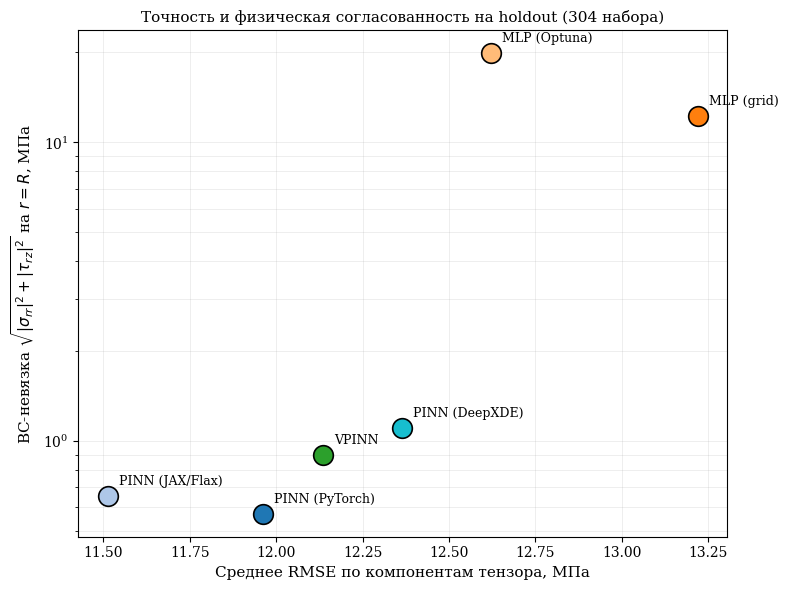

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name in BUNDLES:
    yp = predictions[name]
    rmse_macro = float(np.mean([np.sqrt(mean_squared_error(y_hold[:, i], yp[:, i]))
                                 for i in range(4)]))
    bc_comb = np.sqrt(bc_data[name]["srr_mean"]**2 + bc_data[name]["trz_mean"]**2)
    ax.scatter(rmse_macro, bc_comb, s=200, color=MODEL_COLORS[name],
                edgecolor="black", linewidth=1.2, zorder=5)
    ax.annotate(MODEL_LABELS[name], (rmse_macro, bc_comb),
                 xytext=(8, 8), textcoords="offset points", fontsize=9)
ax.set_yscale("log")
ax.set_xlabel(r"Среднее RMSE по компонентам тензора, МПа", fontsize=11)
ax.set_ylabel(r"BC-невязка $\sqrt{|\sigma_{rr}|^2+|\tau_{rz}|^2}$ на $r=R$, МПа",
                fontsize=11)
ax.set_title("Точность и физическая согласованность на holdout (304 набора)",
              fontsize=11)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/fig_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

## Ячейка 7. Установка scikit-posthocs для теста Неменьи

In [8]:
%pip install -q scikit-posthocs

## Ячейка 8. Тесты Фридмана и Неменьи на 304 holdout-наборах

Для каждой пары $(набор \times модель)$ вычисляется RMSE по 20 радиальным точкам профиля. Тест Фридмана проверяет одну глобальную $H_0$, пост-хок Неменьи даёт попарные $p$-значения и разности средних рангов.

In [9]:
from scipy import stats
from scipy.stats import studentized_range
import scikit_posthocs as sp

MODELS_ORDERED = list(BUNDLES.keys())
K = len(MODELS_ORDERED)
N = len(hold_sets)

# Per-set RMSE по 4 компонентам и по vM
rmse_pc = np.zeros((N, K, 4), dtype=np.float32)
rmse_vm = np.zeros((N, K), dtype=np.float32)
for j, name in enumerate(MODELS_ORDERED):
    yp = predictions[name]
    for s in range(N):
        yt_s = y_hold[s*N_R:(s+1)*N_R]
        yp_s = yp[s*N_R:(s+1)*N_R]
        rmse_pc[s, j] = np.sqrt(np.mean((yt_s - yp_s)**2, axis=0))
        vm_t = von_mises(yt_s); vm_p = von_mises(yp_s)
        rmse_vm[s, j] = np.sqrt(np.mean((vm_t - vm_p)**2))

# Friedman per component + vM
print("── Тест Фридмана ──")
friedman = {}
for ci, cn in enumerate(STRESS_NAMES):
    chi2, p = stats.friedmanchisquare(*[rmse_pc[:, j, ci] for j in range(K)])
    friedman[cn] = (chi2, p)
    print(f"  {cn:10s}: χ²={chi2:8.2f}  p={p:.3e}")
chi2_vm, p_vm = stats.friedmanchisquare(*[rmse_vm[:, j] for j in range(K)])
friedman["vM"] = (chi2_vm, p_vm)
print(f"  {'vM':10s}: χ²={chi2_vm:8.2f}  p={p_vm:.3e}")

# Средние ранги
def mean_ranks(M):
    ranks = np.zeros_like(M, dtype=float)
    for i in range(M.shape[0]):
        ranks[i] = stats.rankdata(M[i])
    return ranks.mean(axis=0)

mean_rank = np.zeros((K, 5))
for ci in range(4):
    mean_rank[:, ci] = mean_ranks(rmse_pc[:, :, ci])
mean_rank[:, 4] = mean_ranks(rmse_vm)
rank_df = pd.DataFrame(mean_rank, index=MODELS_ORDERED,
                        columns=STRESS_NAMES + ["vM"])
print("\n── Средние ранги ──")
print(rank_df.round(3))

# Критическая разность (Demsar 2006)
CD = (studentized_range.ppf(0.95, K, np.inf) / np.sqrt(2)) * np.sqrt(K*(K+1)/(6*N))
print(f"\n  CD (α=0.05) = {CD:.4f}")

# Nemenyi pairwise
nemenyi = {}
for ci, cn in enumerate(STRESS_NAMES):
    df_c = pd.DataFrame(rmse_pc[:, :, ci], columns=MODELS_ORDERED)
    nemenyi[cn] = sp.posthoc_nemenyi_friedman(df_c)
nemenyi["vM"] = sp.posthoc_nemenyi_friedman(
    pd.DataFrame(rmse_vm, columns=MODELS_ORDERED)
)

print("\n── Парные сравнения по vM ──")
for i in range(K):
    for j in range(i+1, K):
        dr = abs(mean_rank[i, 4] - mean_rank[j, 4])
        p = nemenyi["vM"].iloc[i, j]
        sig = "*" if dr > CD else " "
        print(f"  {MODELS_ORDERED[i]:11s} vs {MODELS_ORDERED[j]:11s}  "
              f"|ΔR|={dr:.3f} {sig}  p={p:.4f}")

── Тест Фридмана ──
  sigma_rr  : χ²=  130.60  p=1.774e-26
  sigma_tt  : χ²=   71.26  p=5.598e-14
  sigma_zz  : χ²=  118.45  p=6.673e-24
  tau_rz    : χ²=  110.20  p=3.726e-22
  vM        : χ²=  110.24  p=3.638e-22

── Средние ранги ──
            sigma_rr  sigma_tt  sigma_zz  tau_rz     vM
MLP-grid       4.076     4.007     4.102   4.128  3.993
MLP-Optuna     4.155     3.605     3.832   3.783  4.030
PINN-torch     3.164     3.605     3.401   3.595  3.309
PINN-dde       3.569     3.661     3.849   3.707  3.773
PINN-jax       2.734     3.316     2.737   2.842  2.839
VPINN          3.303     2.806     3.079   2.944  3.056

  CD (α=0.05) = 0.4324

── Парные сравнения по vM ──
  MLP-grid    vs MLP-Optuna   |ΔR|=0.036    p=0.9999
  MLP-grid    vs PINN-torch   |ΔR|=0.684 *  p=0.0001
  MLP-grid    vs PINN-dde     |ΔR|=0.220    p=0.6947
  MLP-grid    vs PINN-jax     |ΔR|=1.155 *  p=0.0000
  MLP-grid    vs VPINN        |ΔR|=0.938 *  p=0.0000
  MLP-Optuna  vs PINN-torch   |ΔR|=0.720 *  p=0.0000


## Ячейка 9. Боксплоты per-set RMSE

Распределения RMSE по 304 наборам, по одной панели на компоненту тензора.

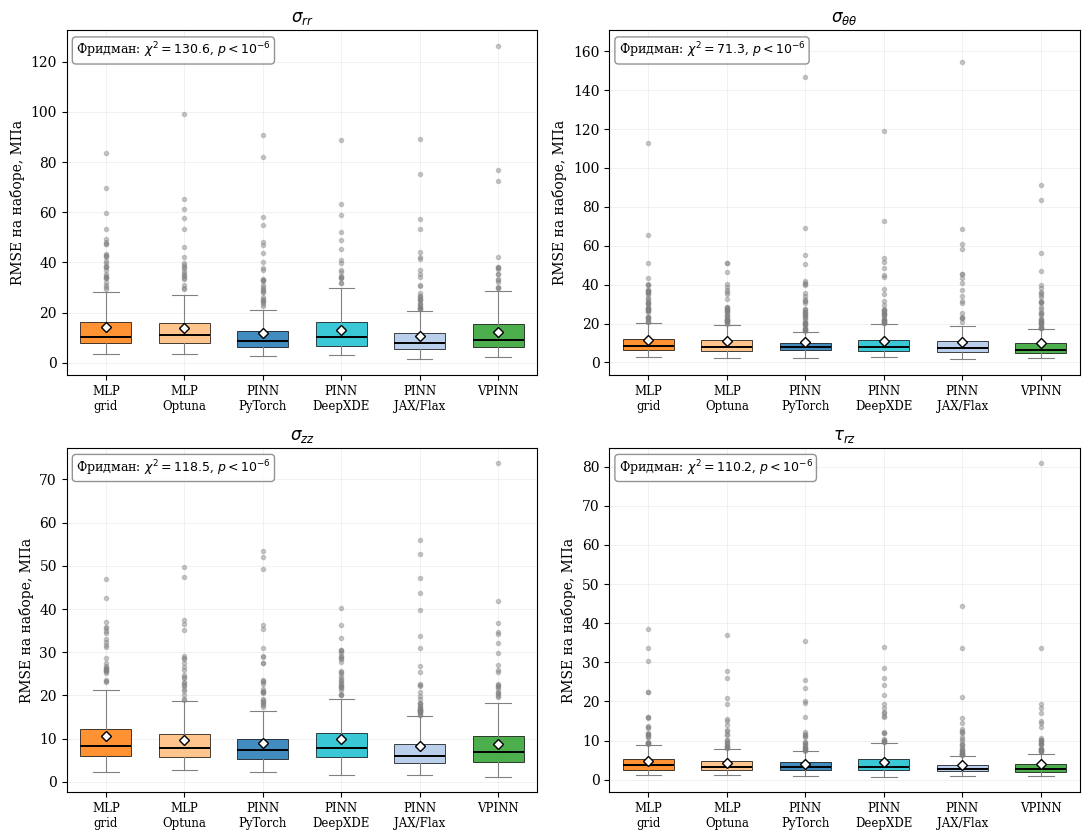

In [10]:
SHORT = ["MLP\ngrid", "MLP\nOptuna", "PINN\nPyTorch",
         "PINN\nDeepXDE", "PINN\nJAX/Flax", "VPINN"]
COLORS_LIST = [MODEL_COLORS[n] for n in MODELS_ORDERED]

fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for k, ax in enumerate(axes.flat):
    data = [rmse_pc[:, j, k] for j in range(K)]
    bp = ax.boxplot(
        data, positions=range(K), widths=0.65,
        patch_artist=True, showmeans=True,
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor="black", markersize=5),
        medianprops=dict(color="black", linewidth=1.4),
        flierprops=dict(marker="o", markersize=3, alpha=0.4,
                        markerfacecolor="grey", markeredgecolor="grey"),
        whiskerprops=dict(color="grey", linewidth=0.8),
        capprops=dict(color="grey", linewidth=0.8),
    )
    for patch, color in zip(bp["boxes"], COLORS_LIST):
        patch.set_facecolor(color); patch.set_alpha(0.85)
        patch.set_edgecolor("black"); patch.set_linewidth(0.6)
    ax.set_xticks(range(K))
    ax.set_xticklabels(SHORT, fontsize=8.5)
    ax.set_ylabel("RMSE на наборе, МПа", fontsize=10)
    ax.set_title(COMP_TEX[k], fontsize=12)
    chi2, p = friedman[STRESS_NAMES[k]]
    p_str = r"$p<10^{-6}$" if p < 1e-6 else f"$p={p:.3e}$"
    ax.text(0.02, 0.97, rf"Фридман: $\chi^2={chi2:.1f}$, {p_str}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="grey", alpha=0.85))
plt.tight_layout()
plt.savefig("/content/fig_friedman_boxplot_no_fem.png", dpi=300, bbox_inches="tight")
plt.show()

## Ячейка 10. Матрица $p$-значений Неменьи

Четыре панели (по одной на компоненту тензора). В каждой ячейке два числа: $p$-значение Неменьи и абсолютная разность средних рангов $|\Delta R|$. Тёмные ячейки — значимые различия.

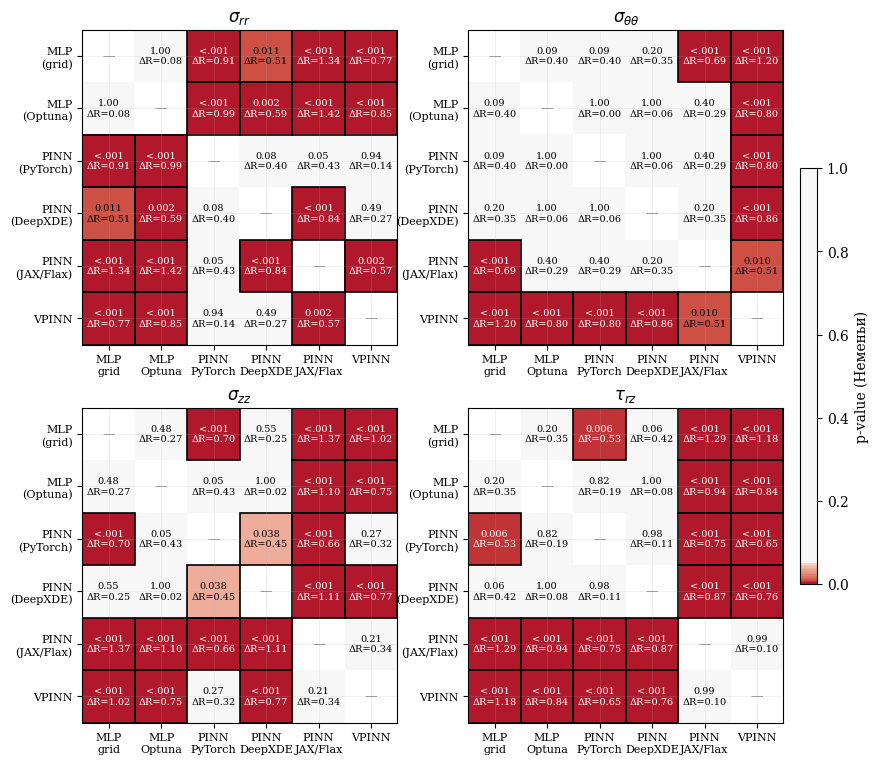

In [11]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

cmap = LinearSegmentedColormap.from_list("nemenyi", [
    (0.00, "#b2182b"), (0.01, "#d6604d"), (0.05, "#fddbc7"),
    (0.05001, "#f7f7f7"), (1.00, "#f7f7f7"),
], N=256)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for k, ax in enumerate(axes.flat):
    pmat = nemenyi[STRESS_NAMES[k]].values
    M = pmat.copy().astype(float); np.fill_diagonal(M, np.nan)
    im = ax.imshow(M, cmap=cmap, vmin=0, vmax=1, aspect="equal")
    for i in range(K):
        for j in range(K):
            if i == j:
                ax.text(j, i, "—", ha="center", va="center",
                        fontsize=9, color="grey"); continue
            v = pmat[i, j]
            dr = abs(mean_rank[i, k] - mean_rank[j, k])
            if v < 0.001:   txt, color = f"<.001\nΔR={dr:.2f}", "white"
            elif v < 0.01:  txt, color = f"{v:.3f}\nΔR={dr:.2f}", "white"
            elif v < 0.05:  txt, color = f"{v:.3f}\nΔR={dr:.2f}", "black"
            else:           txt, color = f"{v:.2f}\nΔR={dr:.2f}", "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=color)
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xticklabels(SHORT, fontsize=8)
    ax.set_yticklabels([MODEL_LABELS[n].replace(" (", "\n(")
                        for n in MODELS_ORDERED], fontsize=8)
    ax.set_title(COMP_TEX[k], fontsize=12)
    for i in range(K):
        for j in range(K):
            if i != j and pmat[i, j] < 0.05:
                ax.add_patch(Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                        edgecolor="black", linewidth=1.2))
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02, aspect=25)
cbar.set_label("p-value (Неменьи)", fontsize=10)
plt.savefig("/content/fig_nemenyi_heatmap_no_fem.png", dpi=300, bbox_inches="tight")
plt.show()

## Ячейка 11. Диаграмма критической разности по интегральной метрике vM

Модели соединены горизонтальной чертой, если разница средних рангов меньше $\mathrm{CD}$.

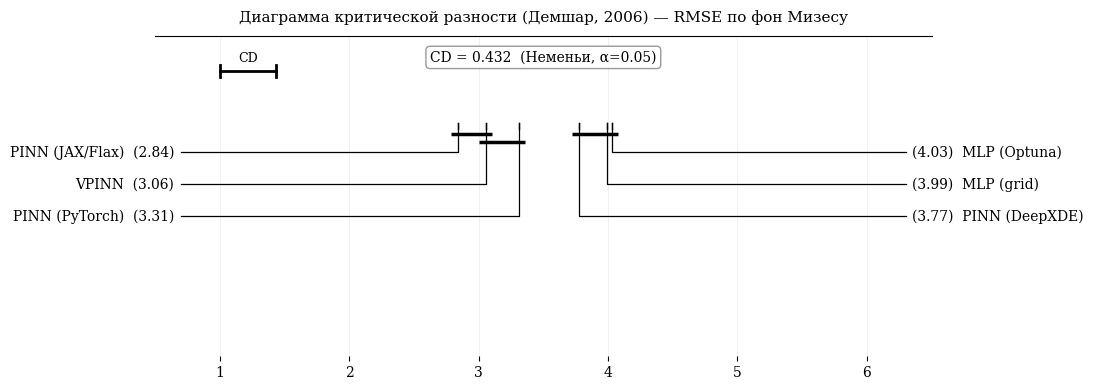

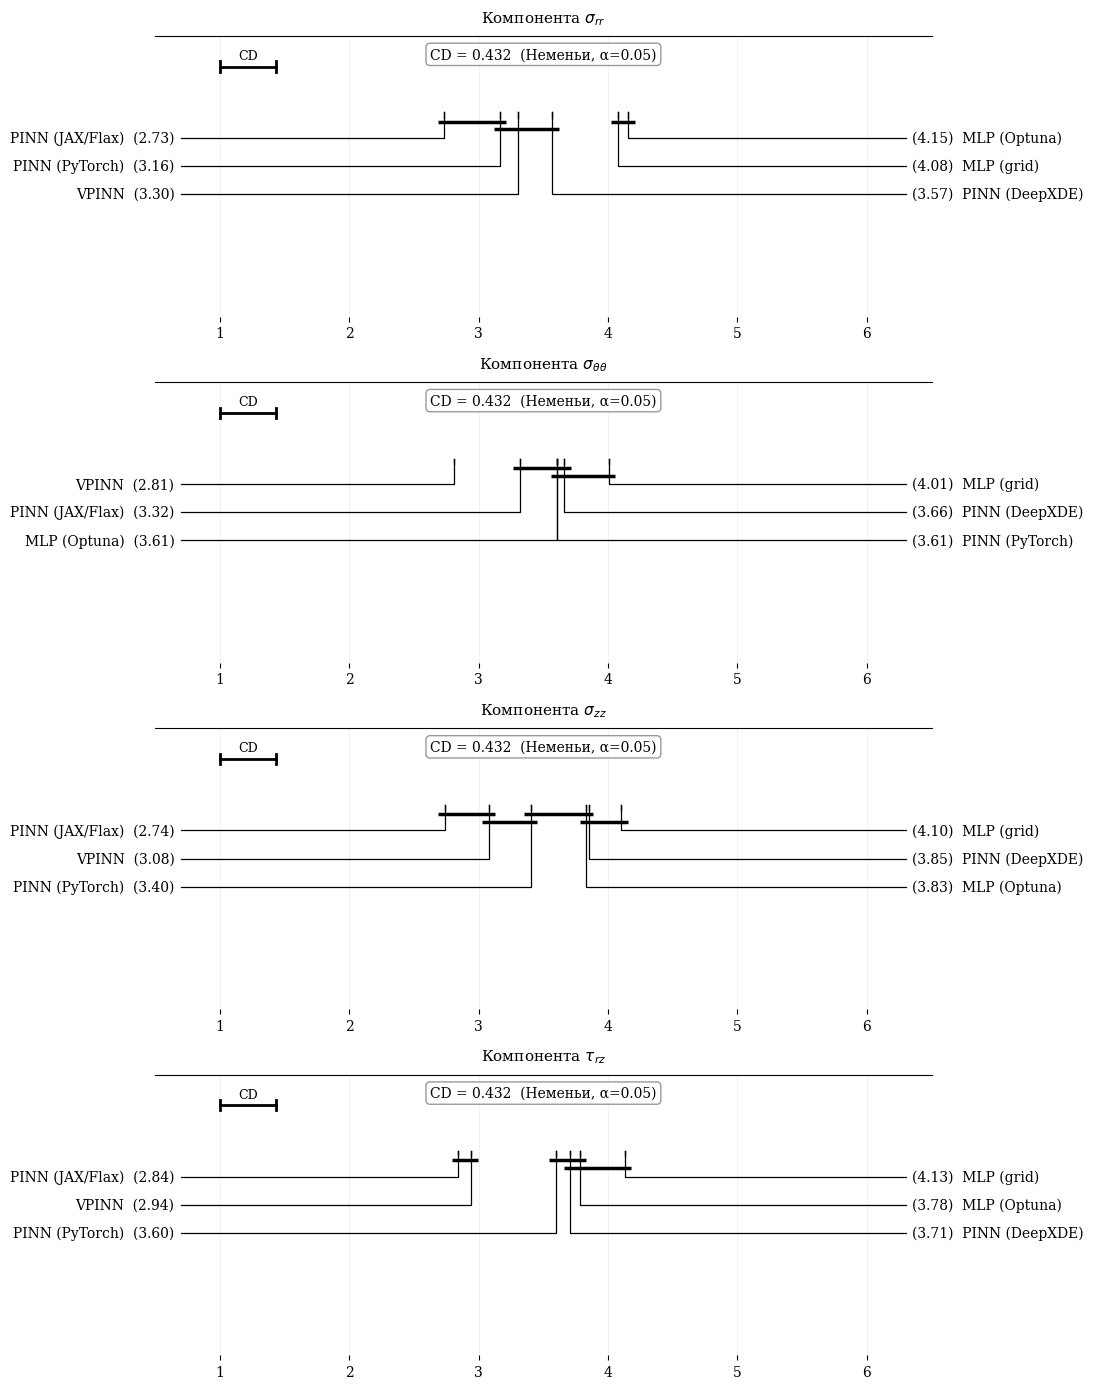

In [12]:
def cd_diagram(ax, ranks, labels, N, alpha=0.05, title=""):
    k = len(ranks)
    cd = (studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2)) * np.sqrt(k*(k+1)/(6*N))
    order = np.argsort(ranks)
    sorted_labels = [labels[i] for i in order]
    sorted_ranks = ranks[order]
    ax.set_xlim(0.5, k + 0.5); ax.set_ylim(0, 5.5); ax.invert_yaxis()
    ax.set_yticks([]); ax.set_xticks(np.arange(1, k + 1))
    ax.tick_params(axis="x", labelsize=10)
    ax.spines["left"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(True); ax.spines["bottom"].set_visible(False)
    ax.set_title(title, fontsize=11, pad=10)
    ax.text(0.5, 0.92, f"CD = {cd:.3f}  (Неменьи, α={alpha})",
            transform=ax.transAxes, ha="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="grey", alpha=0.8))
    cd_y = 0.6
    ax.plot([1, 1+cd], [cd_y, cd_y], "k-", linewidth=2)
    ax.plot([1, 1], [cd_y-0.1, cd_y+0.1], "k-", linewidth=2)
    ax.plot([1+cd, 1+cd], [cd_y-0.1, cd_y+0.1], "k-", linewidth=2)
    ax.text(1 + cd/2, cd_y - 0.15, "CD", ha="center", fontsize=9)
    line_y_top = 1.5
    for i in range(k):
        rank = sorted_ranks[i]
        ax.plot([rank, rank], [line_y_top, line_y_top+0.1], color="black", linewidth=1)
    n_left = (k + 1) // 2
    for i in range(n_left):
        rank = sorted_ranks[i]; label = sorted_labels[i]
        y_text = line_y_top + 0.5 + i*0.55
        ax.plot([rank, rank, 0.7], [line_y_top, y_text, y_text],
                color="black", linewidth=0.9)
        ax.text(0.65, y_text, f"{label}  ({rank:.2f})",
                ha="right", va="center", fontsize=10)
    for i in range(n_left, k):
        rank = sorted_ranks[i]; label = sorted_labels[i]
        y_text = line_y_top + 0.5 + (k-1-i)*0.55
        ax.plot([rank, rank, k+0.3], [line_y_top, y_text, y_text],
                color="black", linewidth=0.9)
        ax.text(k+0.35, y_text, f"({rank:.2f})  {label}",
                ha="left", va="center", fontsize=10)
    used_y = []
    bar_y_start = line_y_top + 0.18
    drawn = set()
    cliques = [(i, j) for i in range(k) for j in range(i+1, k)
                if sorted_ranks[j] - sorted_ranks[i] <= cd]
    for ci, cj in sorted(cliques, key=lambda x: x[0]):
        if (ci, cj) in drawn: continue
        group = [ci]
        for jj in range(ci + 1, k):
            if sorted_ranks[jj] - sorted_ranks[ci] <= cd: group.append(jj)
        if len(group) < 2: continue
        for a in group:
            for bb in group:
                if a < bb: drawn.add((a, bb))
        x_start = sorted_ranks[group[0]]; x_end = sorted_ranks[group[-1]]
        y = bar_y_start
        while any((y == uy and not (x_end < ux_a or x_start > ux_b))
                  for uy, ux_a, ux_b in used_y):
            y += 0.15
        used_y.append((y, x_start, x_end))
        ax.plot([x_start - 0.05, x_end + 0.05], [y, y], color="black",
                linewidth=2.5, solid_capstyle="butt")

fig, ax = plt.subplots(figsize=(11, 4))
cd_diagram(ax, mean_rank[:, 4],
           [MODEL_LABELS[n] for n in MODELS_ORDERED], N=N,
           title=r"Диаграмма критической разности (Демшар, 2006) "
                  r"— RMSE по фон Мизесу")
plt.tight_layout()
plt.savefig("/content/fig_cd_diagram_no_fem.png", dpi=300, bbox_inches="tight")
plt.show()

# CD-диаграммы по каждой компоненте
fig, axes = plt.subplots(4, 1, figsize=(11, 14))
for k, ax in enumerate(axes):
    cd_diagram(ax, mean_rank[:, k],
               [MODEL_LABELS[n] for n in MODELS_ORDERED], N=N,
               title=f"Компонента {COMP_TEX[k]}")
plt.tight_layout()
plt.savefig("/content/fig_cd_diagram_4comp_no_fem.png", dpi=300, bbox_inches="tight")
plt.show()